# VinDr-CXR DICOM Inspection Notebook

This notebook inspects one VinDr-CXR DICOM file before any preprocessing or augmentation.

**Goals**
- Inspect DICOM metadata
- Understand how many frames/images are stored in the file
- Inspect the pixel array
- Display the original X-ray
- Check image dimensions and intensity values
- Inspect DICOM windowing information when available
- Connect the DICOM image ID with the VinDr-CXR annotation CSV files

In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

from pathlib import Path

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Set the DICOM path

The current project stores DICOM files inside `data/images/`.

In [2]:
IMAGE_FOLDER = Path('data/images')

dicom_files = list(IMAGE_FOLDER.glob('*.dicom'))

print(f'DICOM files found: {len(dicom_files)}')

for file in dicom_files:
    print(file)

DICOM files found: 2
data\images\000434271f63a053c4128a0ba6352c7f.dicom
data\images\0005e8e3701dfb1dd93d53e2ff537b6e.dicom


## 2. Select the DICOM file

For now, we are inspecting the one DICOM file already downloaded.

In [3]:
IMAGE_ID = '0005e8e3701dfb1dd93d53e2ff537b6e'
DICOM_PATH = IMAGE_FOLDER / f'{IMAGE_ID}.dicom'

print('DICOM path:')
print(DICOM_PATH)
print('Exists:', DICOM_PATH.exists())

DICOM path:
data\images\0005e8e3701dfb1dd93d53e2ff537b6e.dicom
Exists: True


## 3. Read the DICOM file

In [4]:
ds = pydicom.dcmread(DICOM_PATH)

print('DICOM loaded successfully.')
print('Number of DICOM data elements:', len(ds))

DICOM loaded successfully.
Number of DICOM data elements: 19


## 4. Inspect important DICOM metadata

This helps distinguish the image itself from the metadata stored alongside it.

In [5]:
important_tags = {
    'SOPClassUID': 'SOP Class UID',
    'SOPInstanceUID': 'SOP Instance UID',
    'Modality': 'Modality',
    'Rows': 'Rows',
    'Columns': 'Columns',
    'SamplesPerPixel': 'Samples per Pixel',
    'PhotometricInterpretation': 'Photometric Interpretation',
    'BitsAllocated': 'Bits Allocated',
    'BitsStored': 'Bits Stored',
    'HighBit': 'High Bit',
    'PixelRepresentation': 'Pixel Representation',
    'NumberOfFrames': 'Number of Frames',
    'WindowCenter': 'Window Center',
    'WindowWidth': 'Window Width',
    'TransferSyntaxUID': 'Transfer Syntax UID'
}

for attribute, label in important_tags.items():
    if attribute == 'TransferSyntaxUID':
        value = ds.file_meta.get('TransferSyntaxUID', 'Not available')
    else:
        value = ds.get(attribute, 'Not available')

    print(f'{label:30}: {value}')

SOP Class UID                 : Not available
SOP Instance UID              : Not available
Modality                      : Not available
Rows                          : 3072
Columns                       : 3072
Samples per Pixel             : 1
Photometric Interpretation    : MONOCHROME2
Bits Allocated                : 16
Bits Stored                   : 14
High Bit                      : 13
Pixel Representation          : 0
Number of Frames              : 1
Window Center                 : 8483
Window Width                  : 11160
Transfer Syntax UID           : 1.2.840.10008.1.2


## 5. Check whether this DICOM contains one frame or multiple frames

A DICOM file can technically contain multiple frames. For this chest X-ray dataset, we need to verify what the selected file actually contains.

In [6]:
number_of_frames = int(ds.get('NumberOfFrames', 1))

print('Number of frames:', number_of_frames)

if number_of_frames == 1:
    print('This DICOM contains one image frame.')
else:
    print('This DICOM contains multiple image frames.')

Number of frames: 1
This DICOM contains one image frame.


## 6. Extract the pixel array

`pixel_array` converts the stored DICOM pixel data into a NumPy array that can be inspected and visualized.

In [7]:
image = ds.pixel_array

print('Pixel array type:', type(image))
print('Shape:', image.shape)
print('Data type:', image.dtype)
print('Minimum pixel value:', image.min())
print('Maximum pixel value:', image.max())
print('Mean pixel value:', image.mean())
print('Standard deviation:', image.std())

Pixel array type: <class 'numpy.ndarray'>
Shape: (3072, 3072)
Data type: uint16
Minimum pixel value: 0
Maximum pixel value: 16383
Mean pixel value: 7755.744097815619
Standard deviation: 3331.188040138861


## 7. Check the array dimensions

For a normal single-frame 2D chest X-ray, the pixel array should have the form:

`(height, width)`

A multi-frame image could have an additional frame dimension.

In [8]:
print('Number of dimensions:', image.ndim)

if image.ndim == 2:
    print('This is a 2D single-frame image.')
elif image.ndim == 3:
    print('This array has three dimensions, so inspect the frame/channel structure.')
else:
    print('Unexpected number of dimensions:', image.ndim)

Number of dimensions: 2
This is a 2D single-frame image.


## 8. Display the original X-ray

No rotation, flip, crop, normalization, or augmentation is applied here.

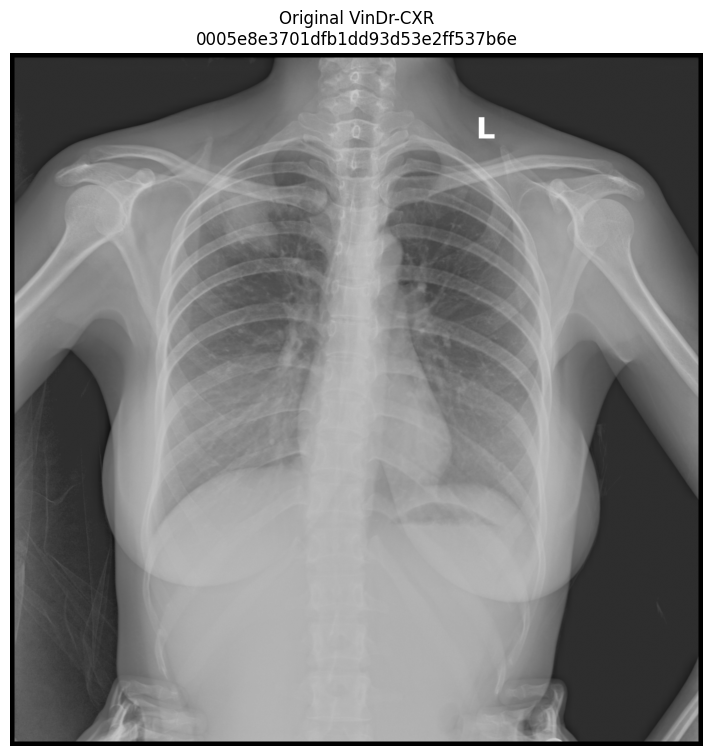

In [9]:
display_image = image.copy()

if ds.get('PhotometricInterpretation') == 'MONOCHROME1':
    display_image = display_image.max() - display_image

plt.figure(figsize=(9, 9))
plt.imshow(display_image, cmap='gray')
plt.title(f'Original VinDr-CXR\n{IMAGE_ID}')
plt.axis('off')
plt.show()

## 9. Inspect the pixel intensity distribution

This histogram shows how pixel values are distributed in the original image.

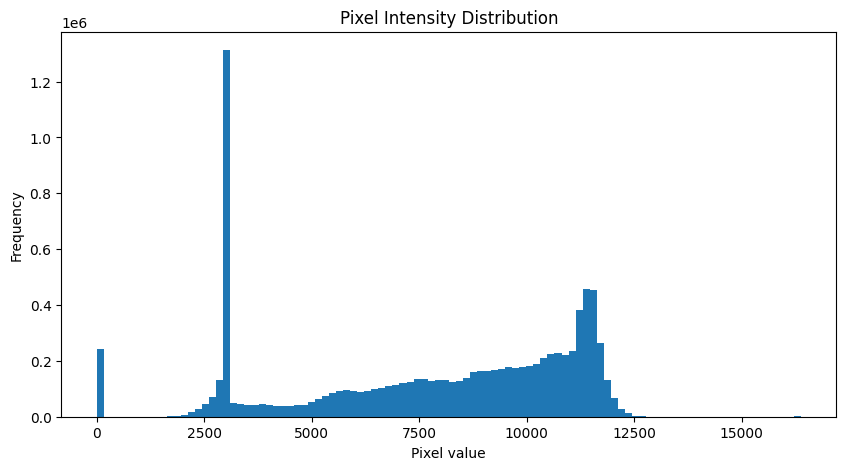

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(image.ravel(), bins=100)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.show()

## 10. Display DICOM metadata

This prints the full metadata dataset. Some fields may contain information that should not be included in public screenshots or reports, so review it before sharing.

In [11]:
print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 154
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Computed Radiography Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 0005e8e3701dfb1dd93d53e2ff537b6e
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0010,0040) Patient's Sex                       CS: 'F'
(0010,1010) Patient's Age                       AS: '028Y'
(0028,0002) Samples per Pixel                   US: 1
(0028,0004) Photometric Interpretation          CS: 'MONOCHROME2'
(0028,0008) Number of Frames                    IS: '1'
(0028,0010) Rows                                US: 3072
(0028,0011) Columns                             US: 

c:\Users\johnm\clinical-notes-nlp\venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '0005e8e3701dfb1dd93d53e2ff537b6e'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


## 11. Connect the DICOM image to the annotation CSV

The same `image_id` is used to connect the DICOM file with the VinDr-CXR annotation records.

In [12]:
ANNOTATIONS_PATH = Path('data/annotations/annotations_train.csv')
LABELS_PATH = Path('data/annotations/image_labels_train.csv')

annotations = pd.read_csv(ANNOTATIONS_PATH)
labels = pd.read_csv(LABELS_PATH)

image_annotations = annotations[
    annotations['image_id'] == IMAGE_ID
].copy()

image_labels = labels[
    labels['image_id'] == IMAGE_ID
].copy()

print('Annotation records:', len(image_annotations))
print('Classification records:', len(image_labels))

display(image_annotations)
display(image_labels)

Annotation records: 5
Classification records: 3


,image_id,rad_id,class_name,x_min,y_min,x_max,y_max
6,0005e8e3701dfb1dd93d53e2ff537b6e,R10,Infiltration,900.956970,587.809021,1205.359985,888.710999
7,0005e8e3701dfb1dd93d53e2ff537b6e,R10,Lung Opacity,900.956970,587.809021,1205.359985,888.710999
8,0005e8e3701dfb1dd93d53e2ff537b6e,R8,Consolidation,932.471985,567.778992,1197.770020,896.408997
9,0005e8e3701dfb1dd93d53e2ff537b6e,R8,Nodule/Mass,932.471985,567.778992,1197.770020,896.408997
10,0005e8e3701dfb1dd93d53e2ff537b6e,R9,Lung Opacity,905.224976,583.223999,1203.270020,890.148010


,image_id,rad_id,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Clavicle fracture,Consolidation,Edema,Emphysema,...,Pneumothorax,Pulmonary fibrosis,Rib fracture,Other lesion,COPD,Lung tumor,Pneumonia,Tuberculosis,Other diseases,No finding
6,0005e8e3701dfb1dd93d53e2ff537b6e,R10,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
7,0005e8e3701dfb1dd93d53e2ff537b6e,R8,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
8,0005e8e3701dfb1dd93d53e2ff537b6e,R9,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0


## 12. Key conclusion

For this selected DICOM, the important question is whether the file itself contains multiple frames or transformations such as horizontal flips.

Augmentations such as flips and rotations are normally **not hidden inside the original DICOM**. They are transformations we create later during preprocessing/training. The original DICOM remains the source image.